# Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import os

# Import and reorganize Data

In [2]:
def import_csv(file_path):
    data = []
    with open(file_path, 'r') as file:
        csv_reader = csv.reader(file)
        for row in csv_reader:
            data.append(row)
    return data

## Import Ctrl

In [38]:
ctrl=[]
ctrl_area=[]

for i in range (5):
    for j in range(6):
        file_path = r'Ctrl_'+str(j)+r'_Serum-Cell'+str(i)+r'.csv'
        if os.path.exists(file_path):
            csv_data = import_csv(file_path)
            ctrl.append(float(csv_data[28][1]))
            ctrl_area.append(float(csv_data[30][1]))
            

ctrl_tv=[]
ctrl_tv_area=[]

for i in range (5):
    for j in range(6):
        file_path = r'tvCtrl_'+str(j)+r'_Serum-Cell'+str(i)+r'.csv'
        if os.path.exists(file_path):
            csv_data = import_csv(file_path)
            ctrl_tv.append(float(csv_data[28][1]))
            ctrl_tv_area.append(float(csv_data[30][1]))

ctrl=np.array(ctrl)
ctrl_tv=np.array(ctrl_tv)

ctrl_mean=np.mean(ctrl)
ctrl_tv_mean=np.mean(ctrl_tv)
ctrl_tot_mean=(ctrl_mean+ctrl_tv_mean)/2
ctrl_mean_difference = np.mean(ctrl-ctrl_tv)
ctrl_normalised_mass=ctrl_mean/np.mean(ctrl_area)
print('ctrl mean: ' + str(ctrl_mean))
print('ctrl_tv mean: ' + str(ctrl_tv_mean))
print('ctrl total mean: ' + str(ctrl_tot_mean))
print('ctrl mean difference: ' +str(ctrl_mean_difference))
print('ctrl proz. diff.: '+ str(100-(ctrl_tv_mean/ctrl_mean*100)))
print('Normalised mean mass:'+str(ctrl_normalised_mass))


ctrl mean: 0.29893166666666665
ctrl_tv mean: 0.17142833333333332
ctrl total mean: 0.23518
ctrl mean difference: 0.12750333333333333
ctrl proz. diff.: 42.653003194710045
Normalised mean mass:0.0002828951479249562


## Import Starved

In [39]:
strv=[]
strv_area=[]

for i in range (5):
    for j in range(6):
        file_path = r'Starved_'+str(j)+r'-Cell'+str(i)+r'.csv'
        if os.path.exists(file_path):
            csv_data = import_csv(file_path)
            strv.append(float(csv_data[28][1]))
            strv_area.append(float(csv_data[30][1]))

strv_tv=[]
strv_tv_area=[]
for i in range (5):
    for j in range(6):
        file_path = r'tvStarved_'+str(j)+r'-Cell'+str(i)+r'.csv'
        if os.path.exists(file_path):
            csv_data = import_csv(file_path)
            strv_tv.append(float(csv_data[28][1]))
            strv_tv_area.append(float(csv_data[30][1]))



strv=np.array(strv)
strv_tv=np.array(strv_tv)

strv_mean=np.mean(strv)
strv_tv_mean=np.mean(strv_tv)
strv_tot_mean = (strv_mean+strv_tv_mean)/2
strv_mean_difference = np.mean(strv_tv-strv)
strv_normalised_mass=strv_mean/np.mean(strv_area)

print('strv mean: ' + str(strv_mean))
print('strv_tv mean: ' + str(strv_tv_mean))
print('strv to mean: ' + str(strv_tot_mean))
print('strv mean difference: ' +str(strv_mean_difference))
print('strv proz. diff.: '+ str(100-(strv_tv_mean/strv_mean*100)))
print('Normalised mean mass:'+str(strv_normalised_mass))


strv mean: 0.3121185714285714
strv_tv mean: 0.1602842857142857
strv to mean: 0.23620142857142856
strv mean difference: -0.15183428571428573
strv proz. diff.: 48.64634777076478
Normalised mean mass:0.0001979586864632956


# Plotting the data

Text(0.5, 1.0, 'Cell Ctrl')

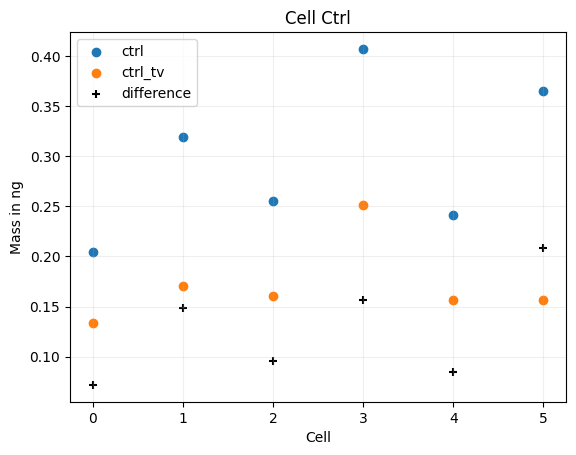

In [31]:
x_ctrl = [0,1,2,3,4,5]
plt.grid(alpha=0.2)

plt.scatter(x_ctrl, ctrl, label='ctrl')
plt.scatter(x_ctrl, ctrl_tv, label='ctrl_tv')
plt.scatter(x_ctrl, abs(ctrl-ctrl_tv), color='black', marker='+', label='difference')

plt.legend()
plt.xlabel('Cell')
plt.ylabel('Mass in ng')
plt.grid(alpha=0.2)
plt.title('Cell Ctrl')


[0.3921  0.46392 0.21535 0.40055 0.25666 0.24532 0.21093]
[0.17359 0.1814  0.145   0.17925 0.15494 0.13594 0.15187]
[0.21851 0.28252 0.07035 0.2213  0.10172 0.10938 0.05906]


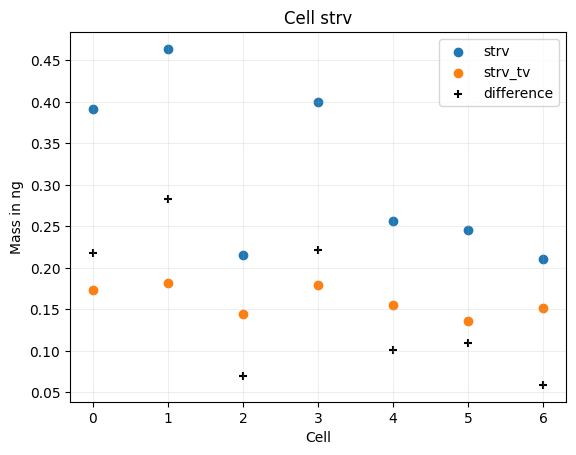

In [32]:
x_strv=[0,1,2,3,4,5,6]
plt.grid(alpha=0.2)

plt.scatter(x_strv, strv, label='strv')
plt.scatter(x_strv, strv_tv, label='strv_tv')
plt.scatter(x_strv, abs(strv-strv_tv), color='black', marker='+', label='difference')

plt.legend()
plt.xlabel('Cell')
plt.ylabel('Mass in ng')
plt.grid(alpha=0.2)
plt.title('Cell strv')

print(strv)
print(strv_tv)
print(strv-strv_tv)

# Comparison normalised

Mean percentage decrease from ctrl to strv: 0.30024007864635327


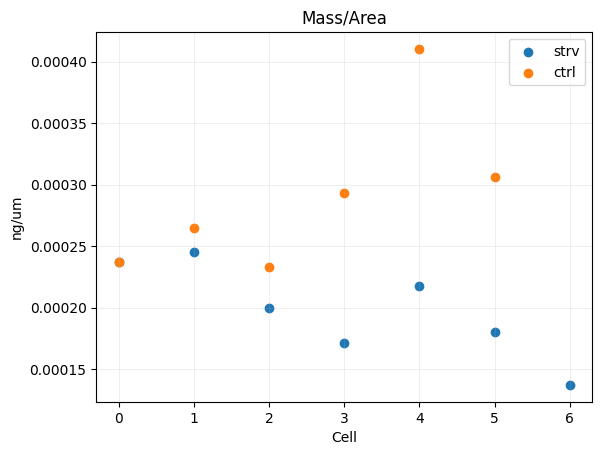

In [49]:
x_strv=[0,1,2,3,4,5,6]
plt.grid(alpha=0.2)

plt.scatter(x_strv, strv/strv_area, label='strv')
plt.scatter(x_ctrl, ctrl/ctrl_area, label='ctrl')
# plt.scatter(x_strv, abs(strv-strv_tv), color='black', marker='+', label='difference')

plt.legend()
plt.xlabel('Cell')
plt.ylabel('ng/um')
plt.grid(alpha=0.2)
plt.title('Mass/Area')

print("Mean percentage decrease from ctrl to strv: "+str(1-(strv_normalised_mass/ctrl_normalised_mass)))

